In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import re
from netwulf import visualize

# Projektet skal indeholde
### Fra opgavebeskrivelsen
- An explanation of the central idea behind your project (what is the idea?, why is it interesting? which datasets did you need to explore the idea?, how did you download them)
- An outline on the elements you'll need to get to your goal & the implementation plan.
- A walk-through of your preliminary data-analysis, addressing
- What is the total size of your data? (MB, number of rows, number of variables, etc)
- What is the network you will be analyzing? (number of nodes? number of links?, degree distributions, what are node attributes?, etc.)
- What is the text you will be analyzing?
- How will you tie the two together?

### Vores ideer
- Er der nogle communities?
- Hvem er de mest aktive

# Fetching the data and collecting in one dataframe

In [2]:
# Reading the dataframes
df_agri = pd.read_csv("df_agri.csv")
df_energy = pd.read_csv("df_energy.csv")
df_enterprise = pd.read_csv("df_enterprise.csv")
df_environmental = pd.read_csv("df_environmental.csv")
df_fish = pd.read_csv("df_fish.csv")
df_industrial = pd.read_csv("df_industrial.csv")
df_info = pd.read_csv("df_info.csv")
df_research = pd.read_csv("df_research.csv")
df_transport = pd.read_csv("df_transport.csv")

In [3]:
#Concat all dataframes into one
df = pd.concat([df_agri, df_energy, df_enterprise, df_environmental, df_fish, df_industrial, df_info,
                df_research, df_transport], ignore_index=True)
df

,document_id,title,rapporteurs,shadow_rapporteurs,summary_link
0,2024/0027(COD),Granting equivalence with EU requirements to M...,VRECIONOVÁ Veronika (ECR),"BUDA Daniel (EPP), CÂRCIU Gheorghe (S&D), PENN...",https://oeil.secure.europarl.europa.eu/oeil/en...
1,2023/0448(COD),Protection of animals during transport and rel...,"BUDA Daniel (EPP), METZ Tilly (Greens/EFA)","GIMÉNEZ LARRAZ Borja (EPP), VIND Marianne (S&D...",https://oeil.secure.europarl.europa.eu/oeil/en...
2,2023/0447(COD),Welfare of dogs and cats and their traceability,VRECIONOVÁ Veronika (ECR),"DE MEO Salvatore (EPP), NARDELLA Dario (S&D), ...",https://oeil.secure.europarl.europa.eu/oeil/en...
3,2023/0413(COD),Monitoring framework for resilient European fo...,"SARGIACOMO Eric (S&D), WIESNER Emma (Renew)","KÖHLER Stefan (EPP), BERNHUBER Alexander (EPP)...",https://oeil.secure.europarl.europa.eu/oeil/en...
4,2023/0410(COD),Standing Forest and Forestry Expert Group,"TOVERI Pekka (EPP), WIESNER Emma (Renew)","BERNHUBER Alexander (EPP), TEMIDO Marta (S&D),...",https://oeil.secure.europarl.europa.eu/oeil/en...
...,...,...,...,...,...
680,2020/2115(INI),Connectivity and EU-Asia relations,BÜTIKOFER Reinhard (Greens/EFA),"DELI Andor (EPP), OLEKAS Juozas (S&D), DZHAMBA...",NaN
681,2019/2205(INI),Implementation report on the road safety aspec...,LUTGEN Benoît (EPP),"UJHELYI István (S&D), GHEORGHE Vlad (Renew), M...",NaN
682,2019/2193(INI),Technical and operational measures for more ef...,DELLI Karima (Greens/EFA),"ADAMOWICZ Magdalena (EPP), TAX Vera (S&D), NAG...",NaN
683,2019/2192(INI),Revision of the Trans-European Transport Netwo...,GIESEKE Jens (EPP),"GARCÍA MUÑOZ Isabel (S&D), RIQUET Dominique (R...",NaN


In [4]:
#Keep track of what the topics are
df_agri['topic'] = 'agri'
df_energy['topic'] = 'energy'
df_enterprise['topic'] = 'enterprise'
df_environmental['topic'] = 'environmental'
df_fish['topic'] = 'fish'
df_industrial['topic'] = 'industrial'
df_info['topic'] = 'info'
df_research['topic'] = 'research'
df_transport['topic'] = 'transport'

df_topic = pd.concat([df_agri, df_energy, df_enterprise, df_environmental, df_fish, df_industrial, df_info,
                df_research, df_transport], ignore_index=True)
df_topic

,document_id,title,rapporteurs,shadow_rapporteurs,summary_link,topic
0,2024/0027(COD),Granting equivalence with EU requirements to M...,VRECIONOVÁ Veronika (ECR),"BUDA Daniel (EPP), CÂRCIU Gheorghe (S&D), PENN...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri
1,2023/0448(COD),Protection of animals during transport and rel...,"BUDA Daniel (EPP), METZ Tilly (Greens/EFA)","GIMÉNEZ LARRAZ Borja (EPP), VIND Marianne (S&D...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri
2,2023/0447(COD),Welfare of dogs and cats and their traceability,VRECIONOVÁ Veronika (ECR),"DE MEO Salvatore (EPP), NARDELLA Dario (S&D), ...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri
3,2023/0413(COD),Monitoring framework for resilient European fo...,"SARGIACOMO Eric (S&D), WIESNER Emma (Renew)","KÖHLER Stefan (EPP), BERNHUBER Alexander (EPP)...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri
4,2023/0410(COD),Standing Forest and Forestry Expert Group,"TOVERI Pekka (EPP), WIESNER Emma (Renew)","BERNHUBER Alexander (EPP), TEMIDO Marta (S&D),...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri
...,...,...,...,...,...,...
680,2020/2115(INI),Connectivity and EU-Asia relations,BÜTIKOFER Reinhard (Greens/EFA),"DELI Andor (EPP), OLEKAS Juozas (S&D), DZHAMBA...",NaN,transport
681,2019/2205(INI),Implementation report on the road safety aspec...,LUTGEN Benoît (EPP),"UJHELYI István (S&D), GHEORGHE Vlad (Renew), M...",NaN,transport
682,2019/2193(INI),Technical and operational measures for more ef...,DELLI Karima (Greens/EFA),"ADAMOWICZ Magdalena (EPP), TAX Vera (S&D), NAG...",NaN,transport
683,2019/2192(INI),Revision of the Trans-European Transport Netwo...,GIESEKE Jens (EPP),"GARCÍA MUÑOZ Isabel (S&D), RIQUET Dominique (R...",NaN,transport


# Network

In [5]:
# Helper function to clean and split names
def split_names(name_str):
    if pd.isna(name_str):
        return []
    return [name.strip() for name in name_str.split(",")]

def create_network(dataframe):
    G = nx.Graph()
    for _, row in dataframe.iterrows():
        rapporteurs = split_names(row["rapporteurs"])
        shadow_rapporteurs = split_names(row["shadow_rapporteurs"])

        participants = rapporteurs + shadow_rapporteurs

        for person in participants:
            if not G.has_node(person):
                G.add_node(person)

        for i, p1 in enumerate(participants):
            for p2 in participants[i+1:]:
                if G.has_edge(p1, p2):
                    G[p1][p2]['weight'] += 1
                else:
                    G.add_edge(p1, p2, weight=1)
    return G

G_collected =create_network(df)
G_agri = create_network(df_agri)
G_energy = create_network(df_energy)
G_enterprise = create_network(df_enterprise)
G_environmental = create_network(df_environmental)
G_fish = create_network(df_fish)
G_industrial = create_network(df_industrial)
G_info = create_network(df_info)
G_research = create_network(df_research)
G_transport = create_network(df_transport)

In [60]:
def threshold_weight(Graph, threshold):
    Graph_filtered = nx.Graph()

    for u, v, data in Graph.edges(data=True):
        if data['weight'] >= threshold:
            Graph_filtered.add_edge(u, v, weight=data['weight'])

    for node in Graph.nodes:
            if node in Graph_filtered:
                Graph_filtered.nodes[node].update(Graph.nodes[node])  # copy node attributes
            elif node not in Graph_filtered:
                Graph_filtered.add_node(node)  # to include even disconnected nodes

            
    return Graph_filtered

G_col_fil = threshold_weight(G_collected, 3)
G_agri_fil = threshold_weight(G_agri,3)
G_energy_fil = threshold_weight(G_energy,3)
G_enterprise_fil = threshold_weight(G_enterprise,3)
G_environmental_fil = threshold_weight(G_environmental,3)
G_fish_fil = threshold_weight(G_fish,3)
G_industrial_fil = threshold_weight(G_industrial,3)
G_info_fil = threshold_weight(G_info,3)
G_research_fil = threshold_weight(G_research,3)


In [58]:
def number_links(Graph):
    degree_dict = dict(Graph.degree())
    degree_df = pd.DataFrame(degree_dict.items(), columns=["Person", "Num_Links"])
    degree_df_sorted = degree_df.sort_values(by="Num_Links", ascending=False)
    return degree_df_sorted

degree_col = number_links(G_collected)
degree_info = number_links(G_info)
degree_agri = number_links(G_agri)
degree_energy = number_links(G_energy)
degree_ent = number_links(G_enterprise)
degree_env = number_links(G_environmental)
degree_fish = number_links(G_fish)
degree_ind = number_links(G_industrial)
degree_res = number_links(G_research)

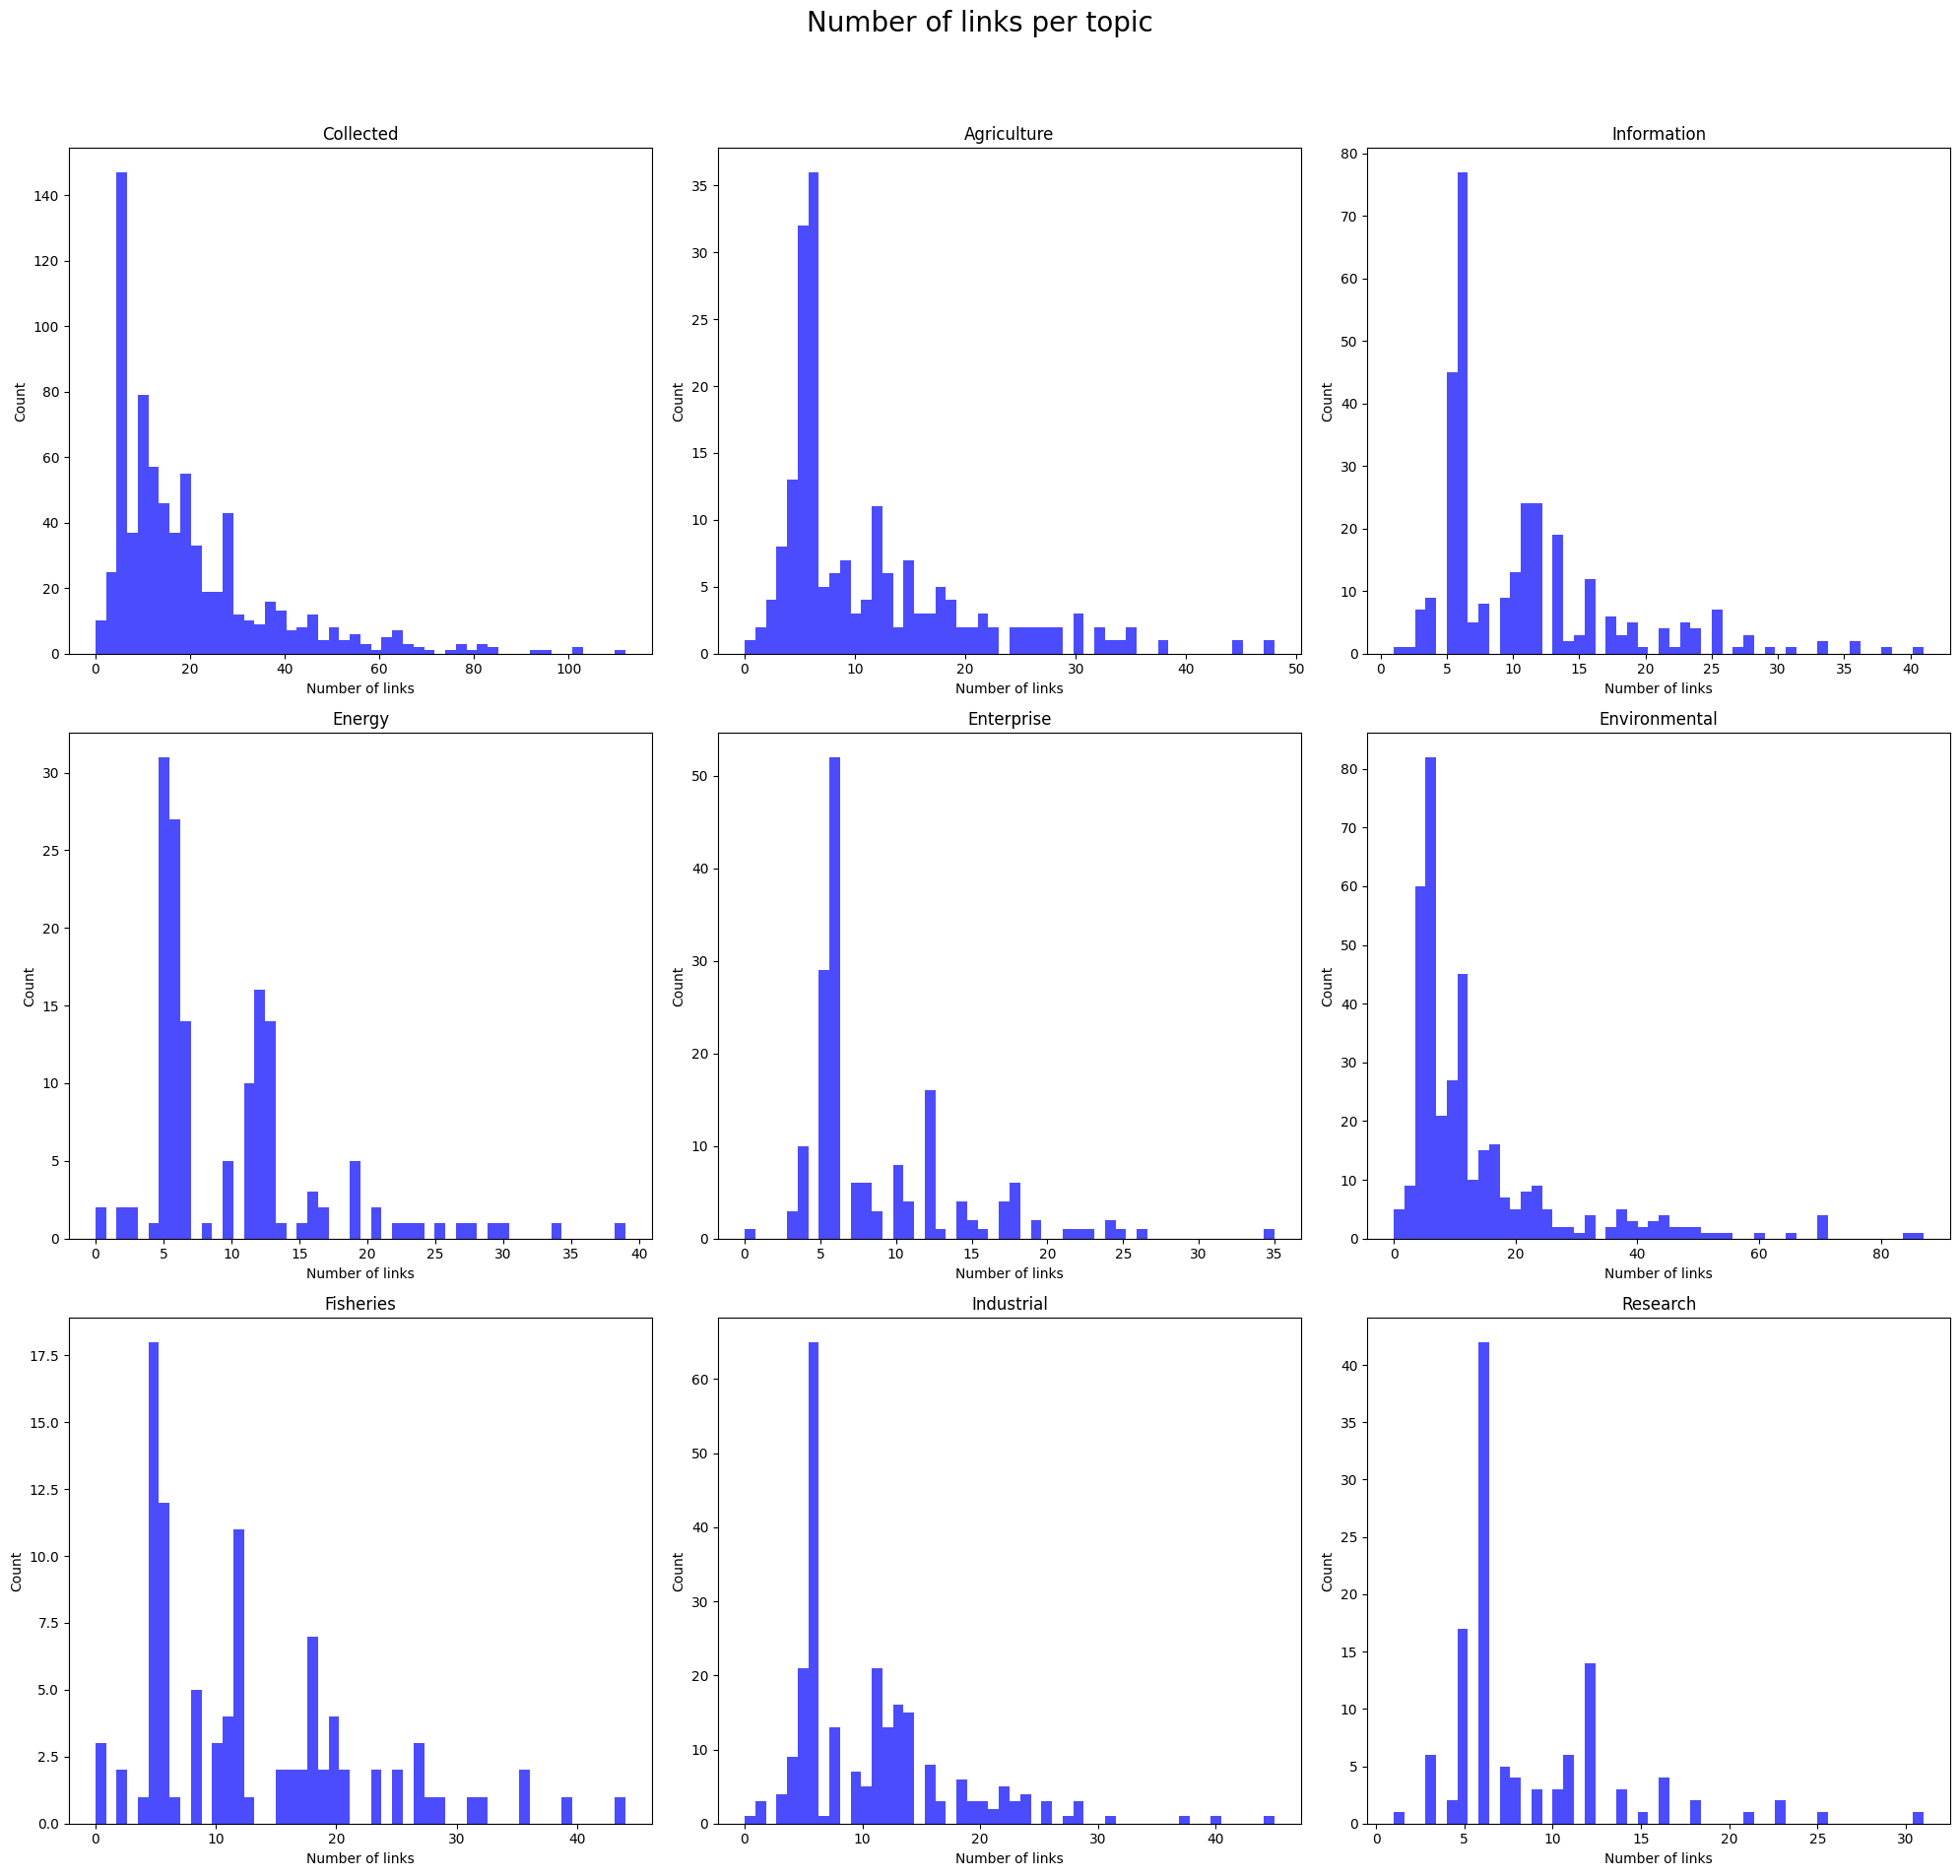

In [59]:
#subplots (histograms) over the 9 topics
fig, axs = plt.subplots(3,3 , figsize=(20,20))
fig.suptitle('Number of links per topic', fontsize=20)
axs[0,0].hist(degree_col['Num_Links'], bins=50, color='blue', alpha=0.7)
axs[0,0].set_title('Collected')
axs[0,1].hist(degree_agri['Num_Links'], bins=50, color='blue', alpha=0.7)
axs[0,1].set_title('Agriculture')
axs[0,2].hist(degree_info['Num_Links'], bins=50, color='blue', alpha=0.7)
axs[0,2].set_title('Information')
axs[1,0].hist(degree_energy['Num_Links'], bins=50, color='blue', alpha=0.7)
axs[1,0].set_title('Energy')
axs[1,1].hist(degree_ent['Num_Links'], bins=50, color='blue', alpha=0.7)
axs[1,1].set_title('Enterprise')
axs[1,2].hist(degree_env['Num_Links'], bins=50, color='blue', alpha=0.7)
axs[1,2].set_title('Environmental')
axs[2,0].hist(degree_fish['Num_Links'], bins=50, color='blue', alpha=0.7)
axs[2,0].set_title('Fisheries')
axs[2,1].hist(degree_ind['Num_Links'], bins=50, color='blue', alpha=0.7)
axs[2,1].set_title('Industrial')
axs[2,2].hist(degree_res['Num_Links'], bins=50, color='blue', alpha=0.7)
axs[2,2].set_title('Research')
axs[0,0].set_xlabel('Number of links')
axs[0,1].set_xlabel('Number of links')
axs[0,2].set_xlabel('Number of links')
axs[1,0].set_xlabel('Number of links')
axs[1,1].set_xlabel('Number of links')
axs[1,2].set_xlabel('Number of links')
axs[2,0].set_xlabel('Number of links')
axs[2,1].set_xlabel('Number of links')
axs[2,2].set_xlabel('Number of links')
axs[0,0].set_ylabel('Count')
axs[0,1].set_ylabel('Count')
axs[0,2].set_ylabel('Count')
axs[1,0].set_ylabel('Count')
axs[1,1].set_ylabel('Count')
axs[1,2].set_ylabel('Count')
axs[2,0].set_ylabel('Count')
axs[2,1].set_ylabel('Count')
axs[2,2].set_ylabel('Count')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

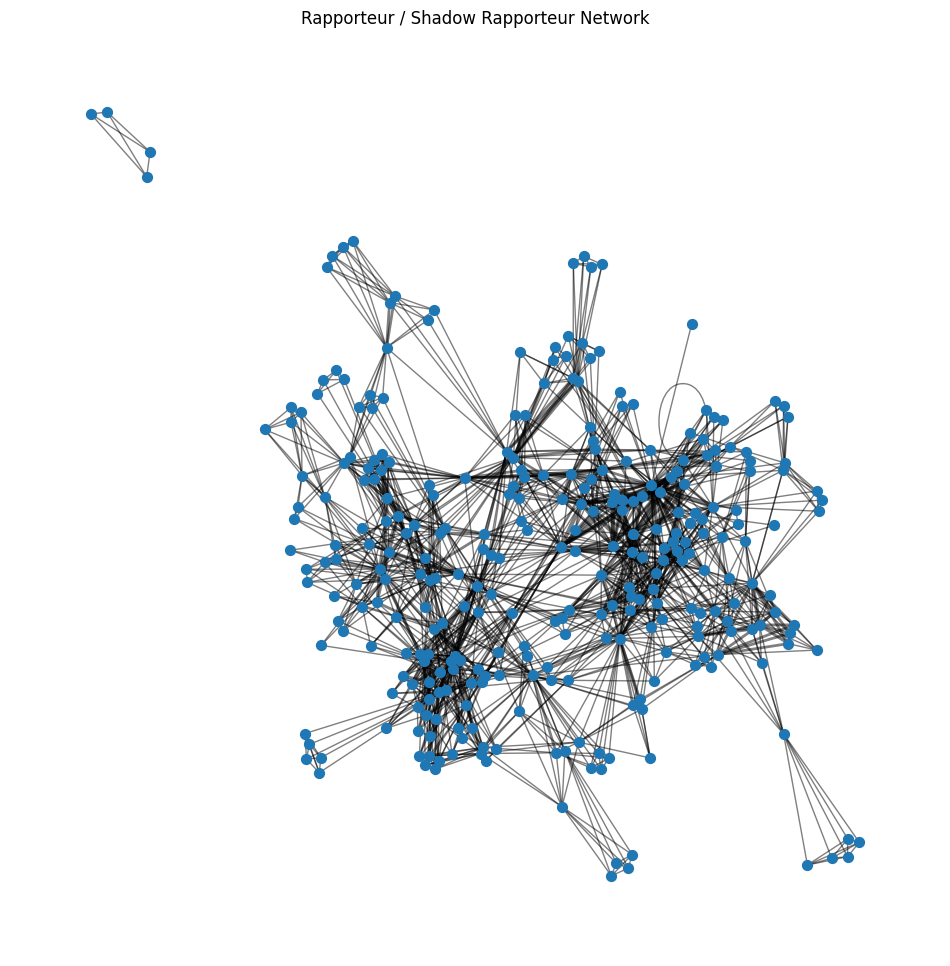

In [43]:
def plot_network(Graph):
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(Graph, k=0.15)
    weights = [Graph[u][v]['weight'] for u,v in Graph.edges()]
    nx.draw_networkx_nodes(Graph, pos, node_size=50)
    nx.draw_networkx_edges(Graph, pos, width=weights, alpha=0.5)
    plt.title("Rapporteur / Shadow Rapporteur Network")
    plt.axis('off')
    plt.show()

plot_network(G_info)

In [46]:
def plot_network_netwulf(Graph):
    visualize(Graph)
    plt.show()

plot_network_netwulf(G_col_fil)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/networkx/readwrite/json_graph/node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


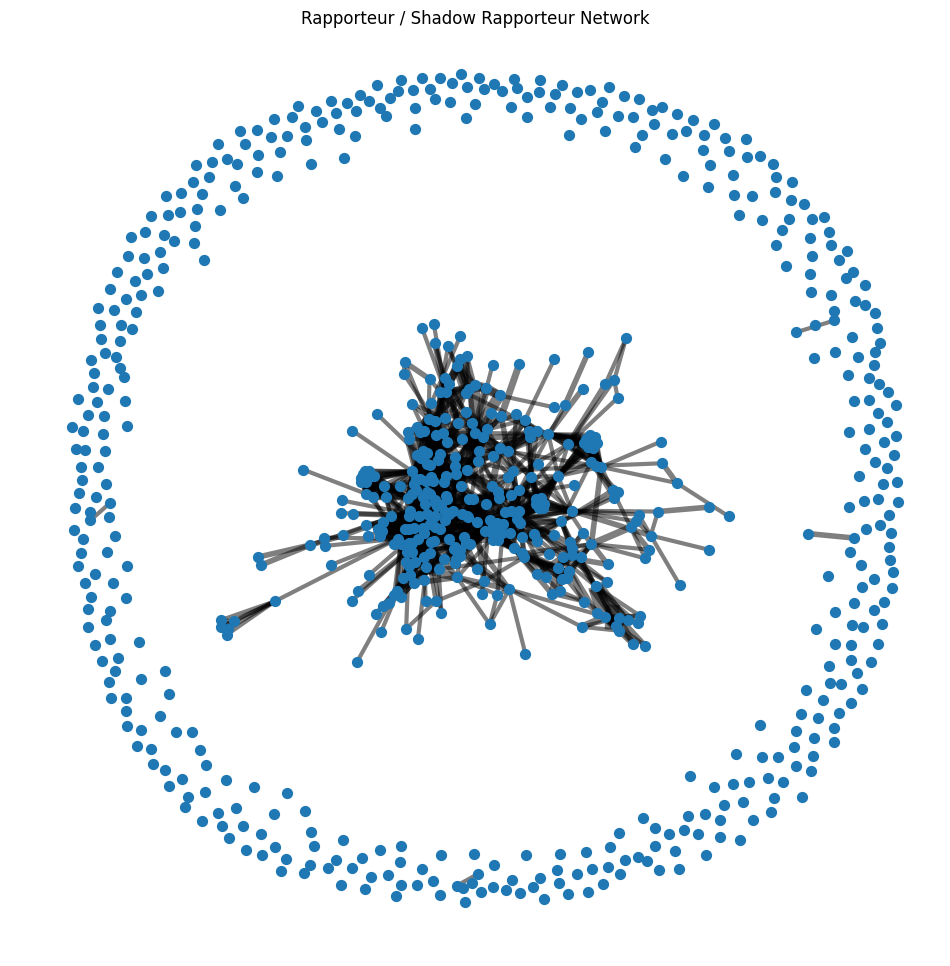

In [45]:
plot_network(G_col_fil)

## Trying to color based on political party

In [35]:
def split_people(cell):
    if pd.isna(cell):
        return []
    return [p.strip() for p in cell.split(",")]

def get_party(person):
    match = re.search(r"\((.*?)\)", person)
    return match.group(1) if match else "NI"

df['rapporteur_list'] = df['rapporteurs'].apply(split_people)
df['shadow_list'] = df['shadow_rapporteurs'].apply(split_people)

df_info['rapporteur_list'] = df_info['rapporteurs'].apply(split_people)
df_info['shadow_list'] = df_info['shadow_rapporteurs'].apply(split_people)

In [36]:
all_people = set([person for sublist in df['rapporteur_list'].tolist() + df['shadow_list'].tolist() for person in sublist])
party_lookup = {person: get_party(person) for person in all_people}
parties = set(party_lookup.values())
parties

{'ALDE',
 'ECR',
 'EFDD',
 'EPP',
 'ESN',
 'GUE/NGL',
 'Greens/EFA',
 'ID',
 'NI',
 'PPE',
 'PfE',
 'Renew',
 'S&D',
 'The Left',
 'Verts/ALE'}

In [37]:
party_colors = {
    "EPP": "#1f77b4",
    "S&D": "#d62728",
    "Renew": "#ff7f0e",
    "Greens/EFA": "#2ca02c",
    "ECR": "#9467bd",
    "ID": "#8c564b",
    "The Left": "#e377c2",
    "NI": "#7f7f7f"
}

In [47]:
def create_network_parties(df, min_weight):
    Graph = nx.Graph()
    for _, row in df.iterrows():
        rapporteurs = row['rapporteur_list']
        shadows = row['shadow_list']
        
        participants = rapporteurs + shadows
        for person in participants:
            if not Graph.has_node(person):
                Graph.add_node(person, party=party_lookup.get(person, "Unknown"))
        
        for i in range(len(participants)):
            for j in range(i + 1, len(participants)):
                p1, p2 = participants[i], participants[j]
                if Graph.has_edge(p1, p2):
                    Graph[p1][p2]['weight'] += 1
                else:
                    Graph.add_edge(p1, p2, weight=1)
    edges_to_remove = [(u, v) for u, v, d in Graph.edges(data=True) if d['weight'] < min_weight]
    Graph.remove_edges_from(edges_to_remove)

    return Graph
G_parties = create_network_parties(df, 3)
G_parties_info = create_network_parties(df_info, 3)


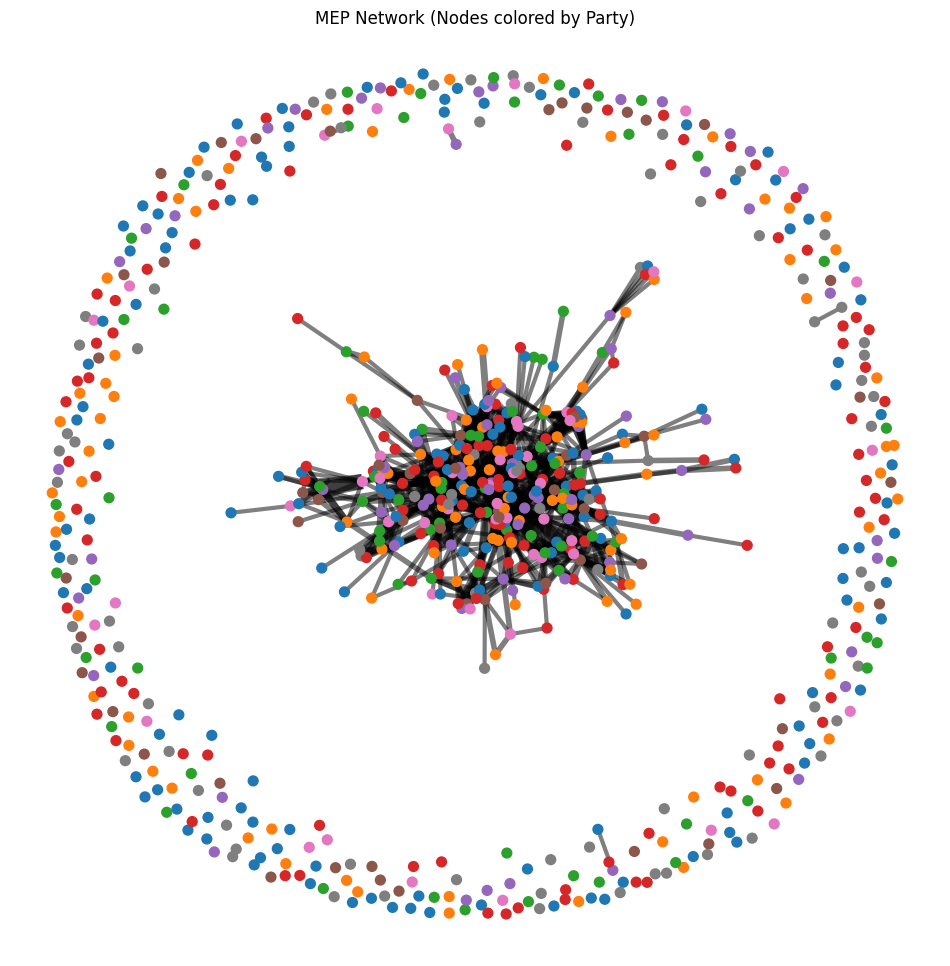

In [49]:
def plot_network_parties(Graph):
    node_colors = [party_colors.get(Graph.nodes[n]['party'], "#7f7f7f") for n in Graph.nodes]

    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(Graph, k=0.15)
    nx.draw_networkx_nodes(Graph, pos, node_color=node_colors, node_size=50)
    nx.draw_networkx_edges(Graph, pos, width=[Graph[u][v]['weight'] for u,v in Graph.edges()], alpha=0.5)
    plt.title("MEP Network (Nodes colored by Party)")
    plt.axis("off")
    plt.show()

plot_network_parties(G_parties)

In [50]:
def plot_network_parties_netwulf(Graph):
    for node in Graph.nodes:
        party = get_party(node)
        Graph.nodes[node]['color'] = party_colors.get(party, "#cccccc")
        Graph.nodes[node]['size'] = Graph.degree(node)

    visualize(Graph)
    plt.show()

plot_network_parties_netwulf(G_parties)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/networkx/readwrite/json_graph/node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


## Coloring based on topic

In [51]:
topic_colors = {
    "agri": "#1f77b4",
    "energy": "#d62728",
    "enterprise": "#ff7f0e",
    "environmental": "#2ca02c",
    "fish": "#9467bd",
    "industrial": "#8c564b",
    "info": "#e377c2",
    "research": "#7f7f7f",
    "transport": "#bcbd22"
}

In [52]:
from collections import defaultdict, Counter
def split_people(cell):
    if pd.isna(cell):
        return []
    return [p.strip() for p in cell.split(",")]

def get_party(person):
    match = re.search(r"\((.*?)\)", person)
    return match.group(1) if match else "NI"

df_topic['rapporteur_list'] = df_topic['rapporteurs'].apply(split_people)
df_topic['shadow_list'] = df_topic['shadow_rapporteurs'].apply(split_people)

person_topics = defaultdict(list)

for _, row in df_topic.iterrows():
    topic = row['topic']
    people = row['rapporteur_list'] + row['shadow_list']
    for person in people:
        person_topics[person].append(topic)

# Step 2: Assign most common topic to each person
person_topic = {
    person: Counter(topics).most_common(1)[0][0]
    for person, topics in person_topics.items()
}

In [54]:
def plot_network_topics_netwulf(Graph):
    for node in Graph.nodes():
        topic = person_topic.get(node, "unknown")
        color = topic_colors.get(topic, "#cccccc")  # default gray if not in dict
        Graph.nodes[node]['color'] = color
        
    visualize(Graph)
    plt.show()

plot_network_topics_netwulf(G_parties)

# Basic inspection

- What is the total size of your data? (MB, number of rows, number of variables, etc)

In [20]:
#Dataset size
print(f"df_topic has {df_topic.shape[0]} rows and {df_topic.shape[1]} columns. The size is {df_topic.memory_usage(index=True).sum() / 1024 * 1024:.2f} bytes.")
print(f"Dataframe looks like:")
df_topic.head()

df_topic has 685 rows and 6 columns. The size is 33012.00 bytes.
Dataframe looks like:


,document_id,title,rapporteurs,shadow_rapporteurs,summary_link,topic
0,2024/0027(COD),Granting equivalence with EU requirements to M...,VRECIONOVÁ Veronika (ECR),"BUDA Daniel (EPP), CÂRCIU Gheorghe (S&D), PENN...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri
1,2023/0448(COD),Protection of animals during transport and rel...,"BUDA Daniel (EPP), METZ Tilly (Greens/EFA)","GIMÉNEZ LARRAZ Borja (EPP), VIND Marianne (S&D...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri
2,2023/0447(COD),Welfare of dogs and cats and their traceability,VRECIONOVÁ Veronika (ECR),"DE MEO Salvatore (EPP), NARDELLA Dario (S&D), ...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri
3,2023/0413(COD),Monitoring framework for resilient European fo...,"SARGIACOMO Eric (S&D), WIESNER Emma (Renew)","KÖHLER Stefan (EPP), BERNHUBER Alexander (EPP)...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri
4,2023/0410(COD),Standing Forest and Forestry Expert Group,"TOVERI Pekka (EPP), WIESNER Emma (Renew)","BERNHUBER Alexander (EPP), TEMIDO Marta (S&D),...",https://oeil.secure.europarl.europa.eu/oeil/en...,agri


In [22]:
print(f"df_agri has {df_agri.shape[0]} rows and {df_agri.shape[1]} columns. The size is {df_agri.memory_usage(index=True).sum() / 1024 * 1024:.2f} bytes.")
print(f"df_energy has {df_energy.shape[0]} rows and {df_energy.shape[1]} columns. The size is {df_energy.memory_usage(index=True).sum() / 1024 * 1024:.2f} bytes.")

df_agri has 88 rows and 6 columns. The size is 4356.00 bytes.
df_energy has 36 rows and 6 columns. The size is 1860.00 bytes.


- What is the network you will be analyzing? (number of nodes? number of links?, degree distributions, what are node attributes?, etc.)

In [10]:
#Number of nodes
print(f"Whole network: {len(G_collected.nodes())}\nAgriculture: {len(G_agri.nodes())}\nEnergy: {len(G_energy.nodes())}\nEnterprise: {len(G_enterprise.nodes())}\nEnvironmental: {len(G_environmental.nodes())}\nFish: {len(G_fish.nodes())}\nIndustrial: {len(G_industrial.nodes())}\nInfo: {len(G_info.nodes())}\nResearch: {len(G_research.nodes())}\nTransport: {len(G_transport.nodes())}")

Whole network: 753
Agriculture: 193
Energy: 149
Enterprise: 166
Environmental: 369
Fish: 97
Industrial: 242
Info: 307
Research: 118
Transport: 227


In [7]:
#Number of links
print(f"Whole network: {len(G_collected.edges())}\nAgriculture: {len(G_agri.edges())}\nEnergy: {len(G_energy.edges())}\nEnterprise: {len(G_enterprise.edges())}\nEnvironmental: {len(G_environmental.edges())}\nFish: {len(G_fish.edges())}\nIndustrial: {len(G_industrial.edges())}\nInfo: {len(G_info.edges())}\nResearch: {len(G_research.edges())}\nTransport: {len(G_transport.edges())}")

Whole network (G): 7495
Agriculture: 1083
Energy: 750
Enterprise: 734
Environmental: 2580
Fish: 635
Industrial: 1319
Info: 1636
Research: 501
Transport: 1423


In [62]:
# Average degree
def average_degree(Graph):
    return sum(dict(Graph.degree()).values())/ len(Graph.nodes())

print(f"Whole network: {average_degree(G_collected)}\nAgriculture: {average_degree(G_agri)}\nEnergy: {average_degree(G_energy)}\nEnterprise: {average_degree(G_enterprise)}\nEnvironmental: {average_degree(G_environmental)}\nFish: {average_degree(G_fish)}\nIndustrial: {average_degree(G_industrial)}\nInfo: {average_degree(G_info)}\nResearch: {average_degree(G_research)}\nTransport: {average_degree(G_transport)}")

Whole network: 19.9070385126162
Agriculture: 11.22279792746114
Energy: 10.06711409395973
Enterprise: 8.843373493975903
Environmental: 13.983739837398375
Fish: 13.092783505154639
Industrial: 10.900826446280991
Info: 10.657980456026058
Research: 8.491525423728813
Transport: 12.537444933920705


In [63]:
#Degree with filtering
print(f"Whole network: {average_degree(G_col_fil)}\nAgriculture: {average_degree(G_agri_fil)}\nEnergy: {average_degree(G_energy_fil)}\nEnterprise: {average_degree(G_enterprise_fil)}\nEnvironmental: {average_degree(G_environmental_fil)}\nFish: {average_degree(G_fish_fil)}\nIndustrial: {average_degree(G_industrial_fil)}\nInfo: {average_degree(G_info_fil)}\nResearch: {average_degree(G_research_fil)}")

Whole network: 3.50066401062417
Agriculture: 0.3316062176165803
Energy: 0.20134228187919462
Enterprise: 0.3253012048192771
Environmental: 0.3794037940379404
Fish: 2.3711340206185567
Industrial: 0.2809917355371901
Info: 0.19543973941368079
Research: 0.3220338983050847
